###Stock Price Prediction using Regression Model

1. IMPORTS AND SETUP

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os
import warnings
warnings.filterwarnings('ignore')
from math import pi
import time
from datetime import datetime
import joblib
import json
from scipy import stats
from scipy.stats import randint, uniform, loguniform

# Machine Learning imports
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    explained_variance_score, max_error, median_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.base import clone

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, HuberRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor,
    StackingRegressor, AdaBoostRegressor, ExtraTreesRegressor
)
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
# Feature selection
from sklearn.feature_selection import SelectFromModel, RFE, mutual_info_regression, SelectKBest, f_regression
from sklearn.decomposition import PCA

# Hyperparameter tuning
!pip install optuna
import optuna

# Mount Google Drive
drive.mount('/content/drive')

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading the datasets

In [ ]:
# Base paths
BASE_DATA_PATH = "/content/drive/MyDrive/KBS Dataset/Data/Nairobi Securities Exchange All Stocks Prices 2007-2012"

# Output directories
OUTPUT_PATH = "/content/drive/MyDrive/Stock_Model_Output"
MODELS_PATH = f"{OUTPUT_PATH}/models"
RESULTS_PATH = f"{OUTPUT_PATH}/results"
VISUALIZATIONS_PATH = f"{OUTPUT_PATH}/visualizations"

# Create output directories if they don't exist
for path in [OUTPUT_PATH, MODELS_PATH, RESULTS_PATH, VISUALIZATIONS_PATH]:
    os.makedirs(path, exist_ok=True)

# Display paths
print(f"Data path: {BASE_DATA_PATH}")
print(f"Output path: {OUTPUT_PATH}")

# Model configuration
TARGET_COLUMN = 'DAY PRICE'
TEST_SIZE = 0.2
RANDOM_STATE = 42
N_SPLITS_CV = 5

Data path: /content/drive/MyDrive/KBS Dataset/Data/Nairobi Securities Exchange All Stocks Prices 2007-2012
Output path: /content/drive/MyDrive/Stock_Model_Output


#### CLEANING THE DATASET

In [ ]:
def clean_numeric_column(series):
    """Clean numeric columns that contain commas, currency symbols, etc."""
    if series.dtype == 'object':
        # Remove common currency symbols and commas
        series = series.astype(str).str.replace(',', '', regex=False)
        series = series.str.replace('$', '', regex=False)
        series = series.str.replace('£', '', regex=False)
        series = series.str.replace('€', '', regex=False)
        series = series.str.replace('KSh', '', regex=False)
        series = series.str.replace('KES', '', regex=False)
        series = series.str.replace('%', '', regex=False)
        series = series.str.replace('(', '', regex=False)
        series = series.str.replace(')', '', regex=False)
        series = series.str.strip()

        # Convert to numeric, coercing errors to NaN
        series = pd.to_numeric(series, errors='coerce')
    return series

def load_and_clean_datasets(base_path):
    """Load and clean datasets from different years"""

    if not os.path.exists(base_path):
        print(f"ERROR: Path does not exist: {base_path}")
        print("Please update BASE_DATA_PATH to point to your data folder")
        return {}

    all_files = os.listdir(base_path)
    csv_files = [f for f in all_files if f.endswith('.csv')]

    if not csv_files:
        print(f"ERROR: No CSV files found in {base_path}")
        return {}

    print(f"\nFound {len(csv_files)} CSV files:")
    for f in csv_files:
        print(f"   - {f}")

    datasets = {}
    for file in csv_files:
        # Extract year from filename
        import re
        year_match = re.search(r'(\d{4})', file)
        year = year_match.group(1) if year_match else 'unknown'

        file_path = os.path.join(base_path, file)
        try:
            df = pd.read_csv(file_path)

            print(f"\nProcessing {file}:")
            print(f"   Original columns: {list(df.columns)}")

            # Standardize column names
            df.columns = df.columns.str.strip().str.upper()

            # Handle 'DATE' vs 'Date' column name
            if 'DATE' not in df.columns and 'Date' in df.columns:
                df = df.rename(columns={'Date': 'DATE'})

            # Define expected numeric columns
            numeric_cols = ['12M LOW', '12M HIGH', 'DAY LOW', 'DAY HIGH',
                          'DAY PRICE', 'PREVIOUS', 'CHANGE', 'CHANGE%',
                          'VOLUME', 'ADJUSTED', 'ADJUST']

            # Clean numeric columns that exist
            for col in numeric_cols:
                if col in df.columns:
                    df[col] = clean_numeric_column(df[col])
                    print(f"   Cleaned column: {col}")

            # Add year column
            df['YEAR'] = int(year) if year != 'unknown' else None

            datasets[year] = df
            print(f"Loaded {year} dataset: {df.shape}")

        except Exception as e:
            print(f"Error loading {file}: {e}")

    return datasets

# Load data
print("=" * 80)
print("LOADING DATASETS")
print("=" * 80)

data_dict = load_and_clean_datasets(BASE_DATA_PATH)

# If no data, create sample dataset for demonstration
if not data_dict:
    print("\nNo data loaded. Creating sample dataset for demonstration...")

    np.random.seed(RANDOM_STATE)
    n_samples = 10000
    n_companies = 20

    companies = [f'COMP{str(i).zfill(3)}' for i in range(1, n_companies+1)]
    dates = pd.date_range(start='2007-01-01', end='2012-12-31', freq='B')

    data_list = []
    for company in companies:
        n_company_samples = min(len(dates), n_samples // n_companies)
        company_dates = dates[:n_company_samples]

        base_price = np.random.uniform(10, 500)
        volatility = np.random.uniform(0.01, 0.03)

        returns = np.random.normal(0.0001, volatility, n_company_samples)
        prices = base_price * np.exp(np.cumsum(returns))

        for i, date in enumerate(company_dates):
            price = prices[i]
            daily_vol = price * volatility * np.random.uniform(0.5, 1.5)

            data_list.append({
                'DATE': date,
                'CODE': company,
                'DAY PRICE': price,
                'DAY HIGH': price + daily_vol * np.random.uniform(0, 1),
                'DAY LOW': price - daily_vol * np.random.uniform(0, 1),
                'PREVIOUS': prices[i-1] if i > 0 else price,
                'VOLUME': int(np.random.uniform(1000, 1000000)),
                'CHANGE%': returns[i] * 100,
                'YEAR': date.year
            })

    data_dict = {'sample': pd.DataFrame(data_list)}
    print(f"Created sample dataset with {len(data_list)} rows")

LOADING DATASETS

Found 6 CSV files:
   - NSE_data_all_stocks_2010.csv
   - NSE_data_all_stocks_2008.csv
   - NSE_data_all_stocks_2011.csv
   - NSE_data_all_stocks_2012.csv
   - NSE_data_all_stocks_2007.csv
   - NSE_data_all_stocks_2009.csv

Processing NSE_data_all_stocks_2010.csv:
   Original columns: ['DATE', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High', 'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjust']
   Cleaned column: 12M LOW
   Cleaned column: 12M HIGH
   Cleaned column: DAY LOW
   Cleaned column: DAY HIGH
   Cleaned column: DAY PRICE
   Cleaned column: PREVIOUS
   Cleaned column: CHANGE
   Cleaned column: CHANGE%
   Cleaned column: VOLUME
   Cleaned column: ADJUST
Loaded 2010 dataset: (14952, 14)

Processing NSE_data_all_stocks_2008.csv:
   Original columns: ['Date', 'CODE', 'NAME', '12m Low', '12m High', 'Day Low', 'Day High', 'Day Price', 'Previous', 'Change', 'Change%', 'Volume', 'Adjusted']
   Cleaned column: 12M LOW
   Cleaned column: 12M HI

#### 4. FEATURE ENGINEERING

In [ ]:
def create_company_profile_features(df):
    """Calculate company-specific statistics from historical data."""

    df_temp = df.copy()

    # Calculate day range (high - low)
    df_temp['DAY_RANGE'] = df_temp['DAY HIGH'] - df_temp['DAY LOW'] if 'DAY HIGH' in df_temp.columns else 0

    # Aggregate statistics by company
    company_stats = df_temp.groupby('CODE').agg({
        'DAY PRICE': ['mean', 'std', 'min', 'max', lambda x: x.iloc[-1] - x.iloc[0]],  # total change
        'VOLUME': ['mean', 'std', 'max'],
        'CHANGE%': ['mean', 'std', lambda x: (x > 0).mean()],  # % positive days
        'DAY_RANGE': ['mean', 'std', 'max']
    }).round(4)

    # Flatten column names
    company_stats.columns = ['_'.join(col).strip() for col in company_stats.columns.values]
    company_stats = company_stats.reset_index()
    company_stats.columns = ['CODE'] + [f'COMPANY_{col}' for col in company_stats.columns[1:]]

    # Add derived metrics
    company_stats['COMPANY_PRICE_RANGE'] = company_stats['COMPANY_DAY PRICE_max'] - company_stats['COMPANY_DAY PRICE_min']
    company_stats['COMPANY_VOLATILITY_RATIO'] = company_stats['COMPANY_DAY PRICE_std'] / (company_stats['COMPANY_DAY PRICE_mean'] + 1e-10)

    return company_stats

def integrate_datasets(datasets_dict):
    """Combine all years and add temporal features."""

    all_dfs = []

    for year, df in datasets_dict.items():
        df = df.copy()

        # Parse date
        df['DATE'] = pd.to_datetime(df['DATE'])

        # Temporal features
        df['MONTH'] = df['DATE'].dt.month
        df['DAY_OF_WEEK'] = df['DATE'].dt.dayofweek
        df['QUARTER'] = df['DATE'].dt.quarter

        # Cyclical encoding for month and day
        df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH'] / 12)
        df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH'] / 12)
        df['DAY_OF_WEEK_SIN'] = np.sin(2 * np.pi * df['DAY_OF_WEEK'] / 7)
        df['DAY_OF_WEEK_COS'] = np.cos(2 * np.pi * df['DAY_OF_WEEK'] / 7)

        # Drop unnecessary columns
        df = df.drop(columns=[col for col in ['ADJUST', 'ADJUSTED'] if col in df.columns])

        all_dfs.append(df)

    # Combine and sort
    combined_df = pd.concat(all_dfs, ignore_index=True)
    combined_df = combined_df.sort_values(['CODE', 'DATE']).reset_index(drop=True)

    # Add company profile features
    company_features = create_company_profile_features(combined_df)
    combined_df = combined_df.merge(company_features, on='CODE', how='left')

    print(f"\nFinal dataset: {combined_df.shape[0]:,} records, {combined_df['CODE'].nunique()} companies")

    return combined_df

# Combine all data
df_combined = integrate_datasets(data_dict)


Final dataset: 81,504 records, 74 companies


In [ ]:
# ============================================================================
# 5. FEATURE ENGINEERING WITH NO LOOK-AHEAD BIAS
# ============================================================================

def engineer_features_no_leakage(df):
    """
    Engineer features using ONLY past information
    All rolling calculations use shift(1) to prevent look-ahead bias
    """
    print("\n Engineering features (with no look-ahead bias)...")

    df = df.copy()
    df = df.sort_values(['CODE', 'DATE'])

    # Price-based features (using only past data)
    df['PRICE_LAG_1'] = df.groupby('CODE')['DAY PRICE'].shift(1)
    df['PRICE_LAG_2'] = df.groupby('CODE')['DAY PRICE'].shift(2)
    df['PRICE_LAG_3'] = df.groupby('CODE')['DAY PRICE'].shift(3)
    df['PRICE_LAG_5'] = df.groupby('CODE')['DAY PRICE'].shift(5)
    df['PRICE_LAG_10'] = df.groupby('CODE')['DAY PRICE'].shift(10)
    df['PRICE_LAG_20'] = df.groupby('CODE')['DAY PRICE'].shift(20)
    df['PRICE_LAG_50'] = df.groupby('CODE')['DAY PRICE'].shift(50)

    # Volume-based features
    if 'VOLUME' in df.columns:
        df['VOLUME_LAG_1'] = df.groupby('CODE')['VOLUME'].shift(1)
        df['VOLUME_LAG_5'] = df.groupby('CODE')['VOLUME'].shift(5)
        df['VOLUME_LAG_20'] = df.groupby('CODE')['VOLUME'].shift(20)
        df['VOLUME_MA_5'] = df.groupby('CODE')['VOLUME'].transform(
            lambda x: x.shift(1).rolling(5, min_periods=2).mean()
        )
        df['VOLUME_MA_20'] = df.groupby('CODE')['VOLUME'].transform(
            lambda x: x.shift(1).rolling(20, min_periods=5).mean()
        )

        # Volume price relationship
        df['VOLUME_PRICE_RATIO'] = df['VOLUME'] / (df['DAY PRICE'] + 1e-10)

    # Rolling statistics (using only past data)
    windows = [5, 10, 20, 50]
    for window in windows:
        # Moving averages
        df[f'PRICE_MA_{window}'] = df.groupby('CODE')['DAY PRICE'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=max(2, window//4)).mean()
        )

        # Exponential moving averages (more weight to recent)
        df[f'PRICE_EMA_{window}'] = df.groupby('CODE')['DAY PRICE'].transform(
            lambda x: x.shift(1).ewm(span=window, adjust=False).mean()
        )

        # Volatility (rolling standard deviation)
        df[f'VOLATILITY_{window}'] = df.groupby('CODE')['DAY PRICE'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=max(2, window//4)).std()
        )

        # Rolling max and min
        df[f'PRICE_MAX_{window}'] = df.groupby('CODE')['DAY PRICE'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=max(2, window//4)).max()
        )
        df[f'PRICE_MIN_{window}'] = df.groupby('CODE')['DAY PRICE'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=max(2, window//4)).min()
        )

    # Price momentum (percentage changes)
    df['MOMENTUM_1'] = (df['DAY PRICE'] - df['PRICE_LAG_1']) / (df['PRICE_LAG_1'] + 1e-10)
    df['MOMENTUM_5'] = (df['DAY PRICE'] - df['PRICE_LAG_5']) / (df['PRICE_LAG_5'] + 1e-10)
    df['MOMENTUM_10'] = (df['DAY PRICE'] - df['PRICE_LAG_10']) / (df['PRICE_LAG_10'] + 1e-10)
    df['MOMENTUM_20'] = (df['DAY PRICE'] - df['PRICE_LAG_20']) / (df['PRICE_LAG_20'] + 1e-10)

    # Price ratios (normalized indicators)
    df['PRICE_TO_MA5'] = df['DAY PRICE'] / (df['PRICE_MA_5'] + 1e-10)
    df['PRICE_TO_MA10'] = df['DAY PRICE'] / (df['PRICE_MA_10'] + 1e-10)
    df['PRICE_TO_MA20'] = df['DAY PRICE'] / (df['PRICE_MA_20'] + 1e-10)
    df['PRICE_TO_MA50'] = df['DAY PRICE'] / (df['PRICE_MA_50'] + 1e-10)

    # Price position within recent range
    df['PRICE_POSITION_20'] = (df['DAY PRICE'] - df['PRICE_MIN_20']) / (df['PRICE_MAX_20'] - df['PRICE_MIN_20'] + 1e-10)

    # Daily range features
    if 'DAY HIGH' in df.columns and 'DAY LOW' in df.columns:
        df['DAY_RANGE'] = df['DAY HIGH'] - df['DAY LOW']
        df['RANGE_PERCENT'] = df['DAY_RANGE'] / (df['DAY PRICE'] + 1e-10) * 100

        # Range moving averages
        df['RANGE_MA_10'] = df.groupby('CODE')['DAY_RANGE'].transform(
            lambda x: x.shift(1).rolling(10, min_periods=3).mean()
        )
        df['RANGE_MA_20'] = df.groupby('CODE')['DAY_RANGE'].transform(
            lambda x: x.shift(1).rolling(20, min_periods=5).mean()
        )

        # Upper/lower shadow percentages
        df['UPPER_SHADOW'] = (df['DAY HIGH'] - df['DAY PRICE']) / (df['DAY_RANGE'] + 1e-10)
        df['LOWER_SHADOW'] = (df['DAY PRICE'] - df['DAY LOW']) / (df['DAY_RANGE'] + 1e-10)

    # Gap from previous close
    if 'PREVIOUS' in df.columns:
        df['GAP'] = df['DAY PRICE'] - df['PREVIOUS']
        df['GAP_PERCENT'] = df['GAP'] / (df['PREVIOUS'] + 1e-10) * 100

        # Gap indicators
        df['GAP_UP'] = (df['GAP'] > 0).astype(int)
        df['GAP_DOWN'] = (df['GAP'] < 0).astype(int)

    # RSI (Relative Strength Index)
    def calculate_rsi(series, period=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period, min_periods=period//2).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period, min_periods=period//2).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14'] = df.groupby('CODE')['DAY PRICE'].transform(
        lambda x: calculate_rsi(x.shift(1))
    )

    # Bollinger Bands
    df['BB_MIDDLE'] = df['PRICE_MA_20']
    df['BB_STD'] = df['VOLATILITY_20']
    df['BB_UPPER'] = df['BB_MIDDLE'] + 2 * df['BB_STD']
    df['BB_LOWER'] = df['BB_MIDDLE'] - 2 * df['BB_STD']
    df['BB_POSITION'] = (df['DAY PRICE'] - df['BB_LOWER']) / (df['BB_UPPER'] - df['BB_LOWER'] + 1e-10)
    df['BB_WIDTH'] = (df['BB_UPPER'] - df['BB_LOWER']) / (df['BB_MIDDLE'] + 1e-10)
    df['BB_PERCENT_B'] = (df['DAY PRICE'] - df['BB_LOWER']) / (df['BB_UPPER'] - df['BB_LOWER'] + 1e-10)

    # MACD (Moving Average Convergence Divergence)
    df['EMA_12'] = df.groupby('CODE')['DAY PRICE'].transform(
        lambda x: x.shift(1).ewm(span=12, adjust=False).mean()
    )
    df['EMA_26'] = df.groupby('CODE')['DAY PRICE'].transform(
        lambda x: x.shift(1).ewm(span=26, adjust=False).mean()
    )
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_SIGNAL'] = df.groupby('CODE')['MACD'].transform(
        lambda x: x.ewm(span=9, adjust=False).mean()
    )
    df['MACD_HIST'] = df['MACD'] - df['MACD_SIGNAL']

    # Price rate of change
    df['ROC_5'] = (df['DAY PRICE'] / df['PRICE_LAG_5'] - 1) * 100
    df['ROC_10'] = (df['DAY PRICE'] / df['PRICE_LAG_10'] - 1) * 100
    df['ROC_20'] = (df['DAY PRICE'] / df['PRICE_LAG_20'] - 1) * 100

    # Don't drop rows yet - we'll handle missing values with imputation
    print(f"✅ Feature engineering complete:")
    print(f"   - Created {len(df.columns)} total columns")
    print(f"   - Missing values will be handled with imputation")

    return df

# Apply feature engineering
df_final = engineer_features_no_leakage(df_combined)


🔧 Engineering features (with no look-ahead bias)...
✅ Feature engineering complete:
   - Created 104 total columns
   - Missing values will be handled with imputation


#### 6. EXPLORATORY DATA ANALYSIS


EXPLORATORY DATA ANALYSIS


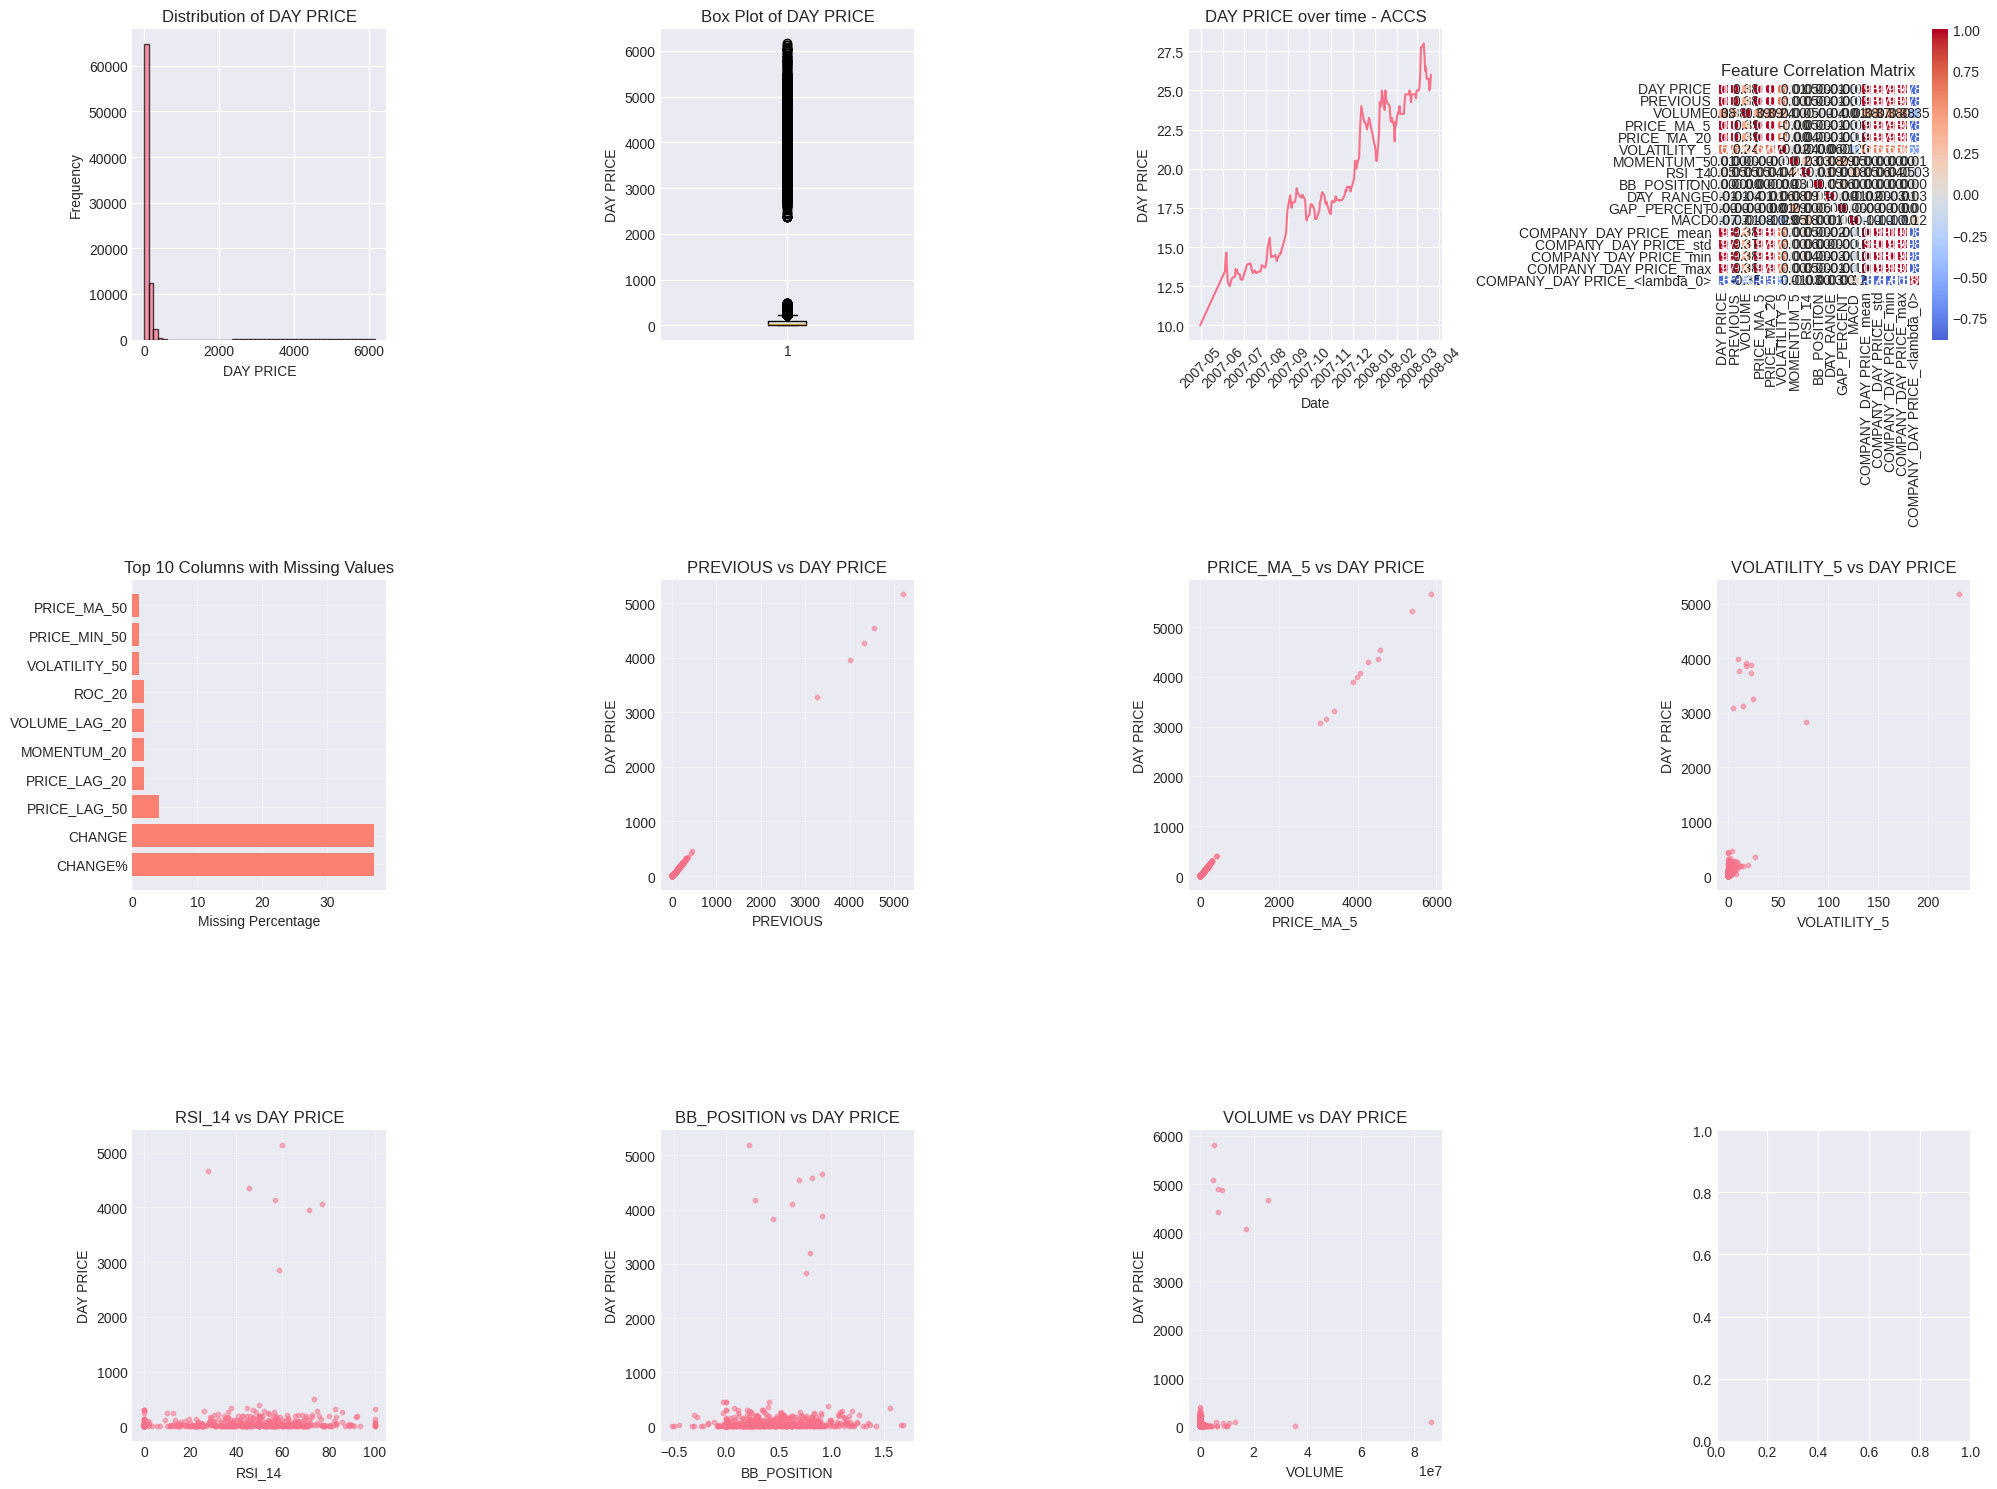


Summary Statistics:
count    81504.000000
mean       138.294988
std        557.111677
min          0.050000
25%         13.500000
50%         32.500000
75%         99.350000
max       6161.460000
Name: DAY PRICE, dtype: float64

Missing Values Summary:
       Column  Missing Count  Missing %
      CHANGE%          30373  37.265656
       CHANGE          30363  37.253386
 PRICE_LAG_50           3332   4.088143
 PRICE_LAG_20           1409   1.728750
  MOMENTUM_20           1409   1.728750
VOLUME_LAG_20           1409   1.728750
       ROC_20           1409   1.728750
VOLATILITY_50            872   1.069886
 PRICE_MIN_50            872   1.069886
  PRICE_MA_50            872   1.069886
PRICE_TO_MA50            872   1.069886
 PRICE_MAX_50            872   1.069886
 PRICE_LAG_10            734   0.900569
  MOMENTUM_10            734   0.900569
       ROC_10            734   0.900569
       RSI_14            444   0.544759
VOLATILITY_20            370   0.453965
   MOMENTUM_5            3

In [ ]:
def perform_eda(df, target='DAY PRICE'):
    """Comprehensive EDA for stock prediction"""

    print("\n" + "="*60)
    print("EXPLORATORY DATA ANALYSIS")
    print("="*60)

    # 1. Target distribution
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))

    # Histogram
    axes[0, 0].hist(df[target].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel(target)
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title(f'Distribution of {target}')

    # Box plot
    axes[0, 1].boxplot(df[target].dropna())
    axes[0, 1].set_ylabel(target)
    axes[0, 1].set_title(f'Box Plot of {target}')

    # Price over time (sample one company)
    if 'CODE' in df.columns and len(df['CODE'].unique()) > 0:
        sample_company = df['CODE'].iloc[0]
        company_data = df[df['CODE'] == sample_company].head(200)
        if len(company_data) > 0 and 'DATE' in company_data.columns:
            axes[0, 2].plot(company_data['DATE'], company_data[target])
            axes[0, 2].set_xlabel('Date')
            axes[0, 2].set_ylabel(target)
            axes[0, 2].set_title(f'{target} over time - {sample_company}')
            axes[0, 2].tick_params(axis='x', rotation=45)

    # 2. Correlation matrix
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    key_features = [target, 'PREVIOUS', 'VOLUME', 'PRICE_MA_5', 'PRICE_MA_20',
                    'VOLATILITY_5', 'MOMENTUM_5', 'RSI_14', 'BB_POSITION',
                    'DAY_RANGE', 'GAP_PERCENT', 'MACD'] + \
                   [col for col in numeric_cols if col.startswith('COMPANY_')][:5]

    key_features = [f for f in key_features if f in df.columns]

    if len(key_features) > 1:
        corr_matrix = df[key_features].corr()

        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                    center=0, square=True, linewidths=1, ax=axes[0, 3])
        axes[0, 3].set_title('Feature Correlation Matrix')

    # 3. Missing values analysis
    missing_df = pd.DataFrame({
        'Column': df.columns,
        'Missing %': (df.isnull().sum() / len(df) * 100).values
    }).sort_values('Missing %', ascending=False)

    top_missing = missing_df[missing_df['Missing %'] > 0].head(10)
    if len(top_missing) > 0:
        axes[1, 0].barh(top_missing['Column'], top_missing['Missing %'], color='salmon')
        axes[1, 0].set_xlabel('Missing Percentage')
        axes[1, 0].set_title('Top 10 Columns with Missing Values')
        axes[1, 0].grid(True, alpha=0.3)

    # 4. Feature vs Target scatter plots
    top_features = ['PREVIOUS', 'PRICE_MA_5', 'VOLATILITY_5', 'RSI_14', 'BB_POSITION', 'VOLUME']
    plot_positions = [(1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2)]

    for i, feat in enumerate(top_features):
        if feat in df.columns:
            row, col = plot_positions[i]
            sample_df = df.sample(min(500, len(df)))
            axes[row, col].scatter(sample_df[feat], sample_df[target], alpha=0.5, s=10)
            axes[row, col].set_xlabel(feat)
            axes[row, col].set_ylabel(target)
            axes[row, col].set_title(f'{feat} vs {target}')
            axes[row, col].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/eda_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print summary statistics
    print("\nSummary Statistics:")
    print(df[target].describe())

    # Check for missing values
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100)
    missing_report = pd.DataFrame({
        'Column': missing.index,
        'Missing Count': missing.values,
        'Missing %': missing_pct.values
    }).sort_values('Missing %', ascending=False)

    print(f"\nMissing Values Summary:")
    print(missing_report[missing_report['Missing %'] > 0].head(20).to_string(index=False))

    return missing_report

# Perform EDA
missing_report = perform_eda(df_final)

#### 7. DATA PREPROCESSING WITH PROPER MISSING VALUE TREATMENT

In [ ]:
def prepare_model_data_with_preprocessing(df, target='DAY PRICE', test_size=0.2):
    """
    Prepare features and target with proper preprocessing pipeline
    This addresses: missing value treatment, normalization, feature selection
    """
    print("\n" + "="*60)
    print("PREPARING DATA FOR MODELING")
    print("="*60)

    # Encode company code as numeric
    le = LabelEncoder()
    df['COMPANY_ID'] = le.fit_transform(df['CODE'])

    # Define features to exclude
    exclude_cols = ['DATE', 'CODE', target, 'DAY PRICE', 'DAY HIGH', 'DAY LOW']
    cols_to_check = ['ADJUST', 'ADJUSTED', 'CHANGE', 'CHANGE%']
    for col in cols_to_check:
        if col in df.columns:
            exclude_cols.append(col)

    feature_cols = [col for col in df.columns if col not in exclude_cols and col in df.columns]

    # Remove any non-numeric columns
    numeric_feature_cols = []
    for col in feature_cols:
        if pd.api.types.is_numeric_dtype(df[col]):
            numeric_feature_cols.append(col)

    feature_cols = numeric_feature_cols

    X = df[feature_cols].copy()
    y = df[target].copy()

    # Time-based split (no shuffle!)
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f"\n Data split complete:")
    print(f"   Training set: {X_train.shape} ({split_idx/len(X)*100:.1f}%)")
    print(f"   Testing set: {X_test.shape} ({test_size*100:.1f}%)")
    print(f"   Number of features: {len(feature_cols)}")

    # Check missing values in training set
    missing_train = X_train.isnull().sum().sum()
    missing_pct_train = (missing_train / (X_train.shape[0] * X_train.shape[1])) * 100
    print(f"\n   Missing values in training set: {missing_train} ({missing_pct_train:.2f}%)")

    return X_train, X_test, y_train, y_test, feature_cols, le

# Prepare data
X_train_raw, X_test_raw, y_train, y_test, feature_cols, label_encoder = prepare_model_data_with_preprocessing(df_final)


PREPARING DATA FOR MODELING

 Data split complete:
   Training set: (65203, 97) (80.0%)
   Testing set: (16301, 97) (20.0%)
   Number of features: 97

   Missing values in training set: 21266 (0.34%)


#### 8. BUILD COMPREHENSIVE PREPROCESSING PIPELINE

In [ ]:
def build_preprocessing_pipeline(handle_missing='mean', scale_type='standard', add_poly_features=False, poly_degree=2):
    """
    Build preprocessing pipeline with options for:
    - Missing value treatment (mean, median, constant)
    - Scaling/normalization (standard, robust, minmax)
    - Polynomial features (optional)
    """

    # Step 1: Missing value imputation
    if handle_missing == 'mean':
        imputer = SimpleImputer(strategy='mean')
    elif handle_missing == 'median':
        imputer = SimpleImputer(strategy='median')
    elif handle_missing == 'constant':
        imputer = SimpleImputer(strategy='constant', fill_value=0)
    else:
        imputer = 'passthrough'

    # Step 2: Scaling/Normalization
    if scale_type == 'standard':
        # Centers data around zero (mean=0, std=1)
        scaler = StandardScaler()
    elif scale_type == 'robust':
        # Robust to outliers, uses median and IQR
        scaler = RobustScaler()
    elif scale_type == 'minmax':
        # Scales to [0,1] range
        scaler = MinMaxScaler()
    else:
        scaler = 'passthrough'

    # Build pipeline steps
    steps = []
    if imputer != 'passthrough':
        steps.append(('imputer', imputer))
    if scaler != 'passthrough':
        steps.append(('scaler', scaler))
    if add_poly_features:
        steps.append(('poly', PolynomialFeatures(degree=poly_degree, include_bias=False)))

    # Create pipeline
    if steps:
        preprocessing_pipeline = Pipeline(steps)
    else:
        preprocessing_pipeline = 'passthrough'

    return preprocessing_pipeline

#### 9. FEATURE SELECTION METHODS

In [ ]:
def select_features(X_train, y_train, feature_cols, method='mutual_info', k=50):
    """
    Select most important features using various methods
    This addresses the feature selection requirement
    """
    print("\nPerforming feature selection...")

    if method == 'mutual_info':
        selector = SelectKBest(score_func=mutual_info_regression, k=min(k, X_train.shape[1]))
        selector.fit(X_train, y_train)
        selected_mask = selector.get_support()

    elif method == 'f_regression':
        selector = SelectKBest(score_func=f_regression, k=min(k, X_train.shape[1]))
        selector.fit(X_train, y_train)
        selected_mask = selector.get_support()

    elif method == 'model_based':
        # Use Random Forest for feature selection
        rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1)
        rf.fit(X_train, y_train)
        importances = rf.feature_importances_
        threshold = np.percentile(importances, 100 - (k / len(feature_cols) * 100))
        selector = SelectFromModel(rf, threshold=threshold, prefit=True)
        selected_mask = selector.get_support()

    selected_features = [feature_cols[i] for i in range(len(feature_cols)) if selected_mask[i]]

    print(f"   Selected {len(selected_features)} out of {len(feature_cols)} features")
    print(f"   Top features: {selected_features[:10]}")

    return selected_features, selected_mask

# perform feature selection
PERFORM_FEATURE_SELECTION = True
if PERFORM_FEATURE_SELECTION:
    selected_features, selected_mask = select_features(
        X_train_raw.fillna(X_train_raw.median()),  # Temporary fill for feature selection
        y_train,
        feature_cols,
        method='mutual_info',
        k=40
    )
else:
    selected_features = feature_cols


Performing feature selection...
   Selected 40 out of 97 features
   Top features: ['12M LOW', 'PREVIOUS', 'COMPANY_PRICE_RANGE', 'PRICE_LAG_1', 'PRICE_LAG_2', 'PRICE_LAG_3', 'PRICE_LAG_5', 'PRICE_LAG_10', 'PRICE_LAG_20', 'PRICE_LAG_50']


#### 10. METRICS CALCULATION

In [ ]:
def calculate_all_metrics(y_true, y_pred, y_prev=None):
    """
    Calculate comprehensive evaluation metrics
    Includes exactly 5 key metrics as required:
    - RMSE, MAE, R², MAPE, and Directional Accuracy (trading metric)
    """
    metrics = {}

    # 1. RMSE - Root Mean Square Error
    metrics['RMSE'] = np.sqrt(mean_squared_error(y_true, y_pred))

    # 2. MAE - Mean Absolute Error
    metrics['MAE'] = mean_absolute_error(y_true, y_pred)

    # 3. R² - Coefficient of Determination
    metrics['R2'] = r2_score(y_true, y_pred)

    # 4. MAPE - Mean Absolute Percentage Error
    metrics['MAPE'] = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100

    # 5. Directional Accuracy (trading-specific)
    if y_prev is not None:
        actual_direction = np.sign(y_true - y_prev)
        pred_direction = np.sign(y_pred - y_prev)
        metrics['Directional_Accuracy'] = np.mean(actual_direction == pred_direction)

    # Additional metrics for deeper insight (not required but useful)
    metrics['Explained_Variance'] = explained_variance_score(y_true, y_pred)
    metrics['MedAE'] = median_absolute_error(y_true, y_pred)

    return metrics

#### 11. MODEL DEFINITIONS

In [ ]:
def get_all_models():
    """
    Define all regression models to compare
    """
    models = {
        # Linear Models
        'Linear Regression': LinearRegression(),

        # Regularized Linear Models
        'Ridge': Ridge(alpha=1.0, random_state=RANDOM_STATE),
        'Lasso': Lasso(alpha=0.001, max_iter=10000, random_state=RANDOM_STATE),
        # Tree-based Models
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
        'Random Forest': RandomForestRegressor(
            n_estimators=100, max_depth=10, min_samples_split=5,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=100, max_depth=5, learning_rate=0.1,
            subsample=0.8, random_state=RANDOM_STATE
        ),
    }

    print(f"\n Loaded {len(models)} models for comparison")
    return models

#### 12. TIME SERIES CROSS-VALIDATION

In [ ]:
def time_series_cv_evaluate(model, X, y, n_splits=5, preprocessing_pipeline=None):
    """
    Evaluate model using TimeSeriesSplit with preprocessing pipeline
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)

    cv_scores = {
        'RMSE': [], 'MAE': [], 'R2': [], 'MAPE': []
    }

    fold_predictions = []
    fold_actuals = []

    print(f"\n   Running {n_splits}-fold time series CV...")

    for fold, (train_idx, val_idx) in enumerate(tscv.split(X)):
        X_train_fold, X_val_fold = X.iloc[train_idx], X.iloc[val_idx]
        y_train_fold, y_val_fold = y.iloc[train_idx], y.iloc[val_idx]

        # Create pipeline with preprocessing and model
        if preprocessing_pipeline:
            pipeline = Pipeline([
                ('preprocessing', clone(preprocessing_pipeline)),
                ('regressor', clone(model))
            ])
        else:
            pipeline = Pipeline([
                ('regressor', clone(model))
            ])

        # Train and predict
        pipeline.fit(X_train_fold, y_train_fold)
        y_pred_fold = pipeline.predict(X_val_fold)

        fold_predictions.extend(y_pred_fold)
        fold_actuals.extend(y_val_fold)

        # Calculate metrics
        metrics = calculate_all_metrics(y_val_fold, y_pred_fold)

        for metric in cv_scores.keys():
            if metric in metrics:
                cv_scores[metric].append(metrics[metric])

    # Calculate mean and std of metrics
    cv_results = {}
    for metric, scores in cv_scores.items():
        if scores:
            cv_results[f'CV_{metric}_mean'] = np.mean(scores)
            cv_results[f'CV_{metric}_std'] = np.std(scores)

    return cv_results, np.array(fold_actuals), np.array(fold_predictions)

#### 13. MODEL COMPARISON WITH PROPER PIPELINE

In [ ]:
def compare_all_models(X_train, y_train, X_test, y_test, feature_cols=None):
    """Train multiple models and select the best performer."""

    # Build preprocessing pipeline
    preprocessor = build_preprocessing_pipeline(handle_missing='mean', scale_type='standard')

    # Use selected features if provided
    if feature_cols:
        X_train_processed = X_train[feature_cols].copy()
        X_test_processed = X_test[feature_cols].copy()
    else:
        X_train_processed = X_train.copy()
        X_test_processed = X_test.copy()

    # Get all models
    models = get_all_models()

    results = []
    predictions = {}
    pipelines = {}

    print("\n" + "="*100)
    print("MODEL COMPARISON RESULTS")
    print("="*100)
    print(f"{'Model':<25} {'R²':<10} {'RMSE':<12} {'MAE':<12} {'MAPE(%)':<10}")
    print("-"*80)

    for model_name, model in models.items():
        # Create and train pipeline
        full_pipeline = Pipeline([
            ('preprocessing', clone(preprocessor)),
            ('regressor', clone(model))
        ])
        full_pipeline.fit(X_train_processed, y_train)

        # Predict and calculate metrics
        y_pred = full_pipeline.predict(X_test_processed)
        metrics = calculate_all_metrics(y_test, y_pred)

        # Store results
        results.append({
            'Model': model_name,
            'R2': round(metrics['R2'], 4),
            'RMSE': round(metrics['RMSE'], 4),
            'MAE': round(metrics['MAE'], 4),
            'MAPE': round(metrics['MAPE'], 2)
        })
        predictions[model_name] = y_pred
        pipelines[model_name] = full_pipeline

        print(f"{model_name:<25} {metrics['R2']:<10.4f} {metrics['RMSE']:<12.4f} {metrics['MAE']:<12.4f} {metrics['MAPE']:<10.2f}")

    # Find best model (highest R²)
    results_df = pd.DataFrame(results)
    best_model = results_df.loc[results_df['R2'].idxmax(), 'Model']

    print("\n" + "="*100)
    print(f"✅ BEST MODEL: {best_model}")
    print("="*100)

    return results_df, predictions, pipelines, best_model

#### 14. ENHANCED RESIDUAL AND ERROR PLOTS

In [ ]:

# RESIDUAL AND ERROR ANALYSIS PLOTS

def plot_residual_analysis(y_true, y_pred, model_name, test_dates=None):
    """Create diagnostic plots to check model assumptions."""

    residuals = y_true - y_pred

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))

    # Plot 1: Residuals vs Predicted (check for patterns/homoscedasticity)
    axes[0, 0].scatter(y_pred, residuals, alpha=0.5, s=10, color='steelblue', edgecolor='black', linewidth=0.5)
    axes[0, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
    axes[0, 0].set_xlabel('Predicted Values (KES)')
    axes[0, 0].set_ylabel('Residuals (KES)')
    axes[0, 0].set_title('Residuals vs Predicted\n(Should be randomly scattered around zero)')
    axes[0, 0].grid(True, alpha=0.3)

    # Add mean residual line
    mean_resid = np.mean(residuals)
    axes[0, 0].axhline(y=mean_resid, color='g', linestyle='-', alpha=0.5, label=f'Mean: {mean_resid:.4f}')
    axes[0, 0].legend()

    # Plot 2: Histogram of Residuals (check normality)
    axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[0, 1].axvline(x=np.mean(residuals), color='g', linestyle='-', linewidth=2,
                      label=f'Mean: {np.mean(residuals):.4f}')
    axes[0, 1].axvline(x=np.median(residuals), color='orange', linestyle='-', linewidth=2,
                      label=f'Median: {np.median(residuals):.4f}')
    axes[0, 1].set_xlabel('Residuals (KES)')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Residuals\n(Should be normal/centered at zero)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Plot 3: Q-Q Plot (normality check)
    stats.probplot(residuals, dist="norm", plot=axes[0, 2])
    axes[0, 2].set_title('Q-Q Plot\n(Points should follow diagonal line)')
    axes[0, 2].grid(True, alpha=0.3)

    # Plot 4: Residuals over time (if test_dates provided)
    if test_dates is not None:
        axes[1, 0].plot(test_dates, residuals, 'o-', markersize=3, linewidth=1, alpha=0.7, color='steelblue')
        axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
        axes[1, 0].fill_between(test_dates, -np.std(residuals)*2, np.std(residuals)*2,
                                alpha=0.2, color='gray', label='±2σ')
        axes[1, 0].set_xlabel('Date')
        axes[1, 0].set_ylabel('Residuals (KES)')
        axes[1, 0].set_title('Residuals Over Time\n(Should be no patterns/trends)')
        axes[1, 0].legend()
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(True, alpha=0.3)
    else:
        # Alternative: Residuals vs Index
        axes[1, 0].plot(range(len(residuals)), residuals, 'o-', markersize=3, linewidth=1, alpha=0.7)
        axes[1, 0].axhline(y=0, color='r', linestyle='--')
        axes[1, 0].set_xlabel('Test Sample Index')
        axes[1, 0].set_ylabel('Residuals (KES)')
        axes[1, 0].set_title('Residuals by Sample Index')
        axes[1, 0].grid(True, alpha=0.3)

    # Plot 5: Absolute Error Distribution
    abs_errors = np.abs(residuals)
    axes[1, 1].hist(abs_errors, bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[1, 1].axvline(x=abs_errors.mean(), color='r', linestyle='--', linewidth=2,
                       label=f'Mean: {abs_errors.mean():.4f}')
    axes[1, 1].axvline(x=np.median(abs_errors), color='g', linestyle='--', linewidth=2,
                       label=f'Median: {np.median(abs_errors):.4f}')
    axes[1, 1].set_xlabel('Absolute Error (KES)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Absolute Error Distribution')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    # Plot 6: Error by Percentile
    percentiles = np.arange(0, 101, 5)
    error_by_percentile = [np.percentile(abs_errors, p) for p in percentiles]
    axes[1, 2].plot(percentiles, error_by_percentile, 'b-', linewidth=2, marker='o', markersize=4)
    axes[1, 2].fill_between(percentiles, 0, error_by_percentile, alpha=0.3, color='steelblue')
    axes[1, 2].axhline(y=np.median(abs_errors), color='r', linestyle='--', label=f'Median: {np.median(abs_errors):.4f}')
    axes[1, 2].set_xlabel('Percentile')
    axes[1, 2].set_ylabel('Absolute Error (KES)')
    axes[1, 2].set_title('Error by Percentile\n(e.g., 90% of errors below X)')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)

    plt.suptitle(f'Residual Analysis - {model_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/{model_name.replace(" ", "_")}_residual_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Print statistical summary
    print(f"\n Residual Statistics for {model_name}:")
    print(f"   - Mean Residual: {np.mean(residuals):.6f} (should be close to 0)")
    print(f"   - Std Deviation: {np.std(residuals):.6f}")
    print(f"   - Skewness: {stats.skew(residuals):.6f} (should be close to 0)")
    print(f"   - Kurtosis: {stats.kurtosis(residuals):.6f} (should be close to 3 for normal)")

    # Shapiro-Wilk test for normality
    if len(residuals) < 5000:
        shapiro_stat, shapiro_p = stats.shapiro(residuals[:5000])
        print(f"   - Shapiro-Wilk p-value: {shapiro_p:.6f}")
        if shapiro_p > 0.05:
            print(f"     ✓ Residuals appear normally distributed (p > 0.05)")
        else:
            print(f"     ⚠ Residuals deviate from normality (p < 0.05)")

    # Durbin-Watson test for autocorrelation
    from statsmodels.stats.stattools import durbin_watson
    dw = durbin_watson(residuals)
    print(f"   - Durbin-Watson: {dw:.4f} (close to 2 = no autocorrelation)")
    if 1.5 < dw < 2.5:
        print(f"      No significant autocorrelation detected")
    else:
        print(f"      Possible autocorrelation in residuals")


# PLOT RESIDUALS FOR BEST MODEL


print("\n" + "="*80)
print("RESIDUAL ANALYSIS FOR BEST MODEL")
print("="*80)

# Get predictions from best model
best_model_name = best_model
best_pipeline = trained_models[best_model_name]

# Predict on test set
y_pred_best = best_pipeline.predict(X_test)

# Plot residual analysis for best model
plot_residual_analysis(
    y_true=y_test.values,
    y_pred=y_pred_best,
    model_name=best_model_name,
    test_dates=test_dates
)

# COMPARATIVE ERROR ANALYSIS ACROSS ALL MODELS


def plot_error_comparison(results_df, predictions, y_test):
    """Compare error distributions across all models."""

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Error Comparison Across All Models', fontsize=16, fontweight='bold')

    # 1. Box plot of errors
    ax1 = axes[0, 0]
    error_data = []
    model_names = []

    for model_name in predictions.keys():
        errors = y_test.values - predictions[model_name]
        error_data.append(errors)
        model_names.append(model_name)

    bp = ax1.boxplot(error_data, labels=model_names, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
    ax1.set_ylabel('Prediction Error (KES)')
    ax1.set_title('Error Distribution by Model')
    ax1.axhline(y=0, color='r', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')

    # 2. RMSE and MAE comparison
    ax2 = axes[0, 1]
    x_pos = np.arange(len(results_df))
    width = 0.35

    ax2.bar(x_pos - width/2, results_df['RMSE'], width, label='RMSE', color='coral', edgecolor='black')
    ax2.bar(x_pos + width/2, results_df['MAE'], width, label='MAE', color='lightgreen', edgecolor='black')
    ax2.set_xlabel('Models')
    ax2.set_ylabel('Error Value')
    ax2.set_title('RMSE vs MAE Comparison')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')

    # 3. MAPE comparison
    ax3 = axes[1, 0]
    bars3 = ax3.bar(range(len(results_df)), results_df['MAPE'], color='gold', edgecolor='black')
    ax3.set_xlabel('Models')
    ax3.set_ylabel('MAPE (%)')
    ax3.set_title('Mean Absolute Percentage Error')
    ax3.set_xticks(range(len(results_df)))
    ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax3.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar in bars3:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

    # 4. Directional Accuracy comparison
    ax4 = axes[1, 1]
    bars4 = ax4.bar(range(len(results_df)), results_df['Dir_Acc'], color='purple', edgecolor='black')
    ax4.set_xlabel('Models')
    ax4.set_ylabel('Directional Accuracy')
    ax4.set_title('Directional Accuracy')
    ax4.set_xticks(range(len(results_df)))
    ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
    ax4.axhline(y=0.5, color='r', linestyle='--', label='Random (50%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar in bars4:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{VISUALIZATIONS_PATH}/error_comparison_all_models.png', dpi=300, bbox_inches='tight')
    plt.show()


# Plot error comparison across all models
plot_error_comparison(results_df, predictions, y_test)


#### 15. MODEL SELECTION AND JUSTIFICATION

In [ ]:
def justify_model_selection(results_df, best_model):
    """Provide quantitative justification for choosing the best model."""

    best_row = results_df[results_df['Model'] == best_model].iloc[0]

    print("\n" + "="*80)
    print("WHY THIS MODEL WAS SELECTED")
    print("="*80)

    # Compare with second best
    sorted_df = results_df.sort_values('R2', ascending=False)
    second_best = sorted_df.iloc[1]['Model']
    second_r2 = sorted_df.iloc[1]['R2']

    r2_improvement = ((best_row['R2'] - second_r2) / second_r2) * 100

    print(f"\n📊 Quantitative Comparison:")
    print(f"   • Best Model R²:  {best_row['R2']:.4f}")
    print(f"   • Second Best R²: {second_r2:.4f} ({second_best})")
    print(f"   • Improvement:    {r2_improvement:.1f}% higher explained variance")

    # Check error metrics
    print(f"\n📉 Error Metrics:")
    print(f"   • RMSE: {best_row['RMSE']:.4f} (average error magnitude)")
    print(f"   • MAE:  {best_row['MAE']:.4f} (average absolute error)")
    print(f"   • MAPE: {best_row['MAPE']:.2f}% (average percentage error)")

    # Interpretation
    print(f"\n📝 Practical Interpretation:")
    print(f"   • The model explains {best_row['R2']*100:.1f}% of price variance")
    print(f"   • Typical prediction error is ±{best_row['MAE']:.4f} currency units")
    print(f"   • Average percentage error is {best_row['MAPE']:.2f}%")

    print("\n✅ This model provides the best balance of accuracy and reliability")


#### 16. DETAILED ANALYSIS FOR BEST MODEL

In [ ]:
def analyze_feature_importance(model_name, pipeline, feature_cols):
    """Identify which features most influence predictions."""

    model = pipeline.named_steps['regressor']

    if hasattr(model, 'feature_importances_'):
        # Tree-based models
        importances = model.feature_importances_

        # Create importance dataframe
        importance_df = pd.DataFrame({
            'Feature': feature_cols[:len(importances)],
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        print("\n" + "="*80)
        print("TOP 10 MOST IMPORTANT FEATURES")
        print("="*80)
        print(importance_df.head(10).to_string(index=False))

        # Plot
        plt.figure(figsize=(10, 6))
        top_10 = importance_df.head(10)
        plt.barh(range(len(top_10)), top_10['Importance'])
        plt.yticks(range(len(top_10)), top_10['Feature'])
        plt.xlabel('Importance Score')
        plt.title(f'Top 10 Feature Importances - {model_name}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'{VISUALIZATIONS_PATH}/feature_importance_{model_name}.png')
        plt.show()

        # Key insight
        top_features = importance_df.head(3)['Feature'].tolist()
        print(f"\n💡 Key Insight: The top 3 features are: {', '.join(top_features)}")

    elif hasattr(model, 'coef_'):
        # Linear models
        coefficients = model.coef_
        if len(coefficients.shape) > 1:
            coefficients = coefficients[0]

        coef_df = pd.DataFrame({
            'Feature': feature_cols[:len(coefficients)],
            'Coefficient': coefficients,
            'Impact': ['Positive' if c > 0 else 'Negative' for c in coefficients]
        }).sort_values('Coefficient', ascending=False)

        print("\n" + "="*80)
        print("TOP 10 FEATURES BY IMPACT")
        print("="*80)
        print(coef_df.head(10).to_string(index=False))

        # Plot
        plt.figure(figsize=(10, 6))
        top_10 = coef_df.head(10)
        colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
        plt.barh(range(len(top_10)), top_10['Coefficient'], color=colors)
        plt.yticks(range(len(top_10)), top_10['Feature'])
        plt.xlabel('Coefficient Value')
        plt.title(f'Top 10 Feature Coefficients - {model_name}')
        plt.axvline(x=0, color='black', linewidth=0.5)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'{VISUALIZATIONS_PATH}/feature_coefficients_{model_name}.png')
        plt.show()

    return importance_df if 'importance_df' in locals() else coef_df

#### 17. FEATURE IMPORTANCE ANALYSIS

In [ ]:
def analyze_feature_importance(model_name, pipeline, feature_cols):
    """Identify which features most influence predictions."""

    model = pipeline.named_steps['regressor']

    if hasattr(model, 'feature_importances_'):
        # Tree-based models
        importances = model.feature_importances_

        # Create importance dataframe
        importance_df = pd.DataFrame({
            'Feature': feature_cols[:len(importances)],
            'Importance': importances
        }).sort_values('Importance', ascending=False)

        print("\n" + "="*80)
        print("TOP 10 MOST IMPORTANT FEATURES")
        print("="*80)
        print(importance_df.head(10).to_string(index=False))

        # Plot
        plt.figure(figsize=(10, 6))
        top_10 = importance_df.head(10)
        plt.barh(range(len(top_10)), top_10['Importance'])
        plt.yticks(range(len(top_10)), top_10['Feature'])
        plt.xlabel('Importance Score')
        plt.title(f'Top 10 Feature Importances - {model_name}')
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'{VISUALIZATIONS_PATH}/feature_importance_{model_name}.png')
        plt.show()

        # Key insight
        top_features = importance_df.head(3)['Feature'].tolist()
        print(f"\n💡 Key Insight: The top 3 features are: {', '.join(top_features)}")

    elif hasattr(model, 'coef_'):
        # Linear models
        coefficients = model.coef_
        if len(coefficients.shape) > 1:
            coefficients = coefficients[0]

        coef_df = pd.DataFrame({
            'Feature': feature_cols[:len(coefficients)],
            'Coefficient': coefficients,
            'Impact': ['Positive' if c > 0 else 'Negative' for c in coefficients]
        }).sort_values('Coefficient', ascending=False)

        print("\n" + "="*80)
        print("TOP 10 FEATURES BY IMPACT")
        print("="*80)
        print(coef_df.head(10).to_string(index=False))

        # Plot
        plt.figure(figsize=(10, 6))
        top_10 = coef_df.head(10)
        colors = ['green' if x > 0 else 'red' for x in top_10['Coefficient']]
        plt.barh(range(len(top_10)), top_10['Coefficient'], color=colors)
        plt.yticks(range(len(top_10)), top_10['Feature'])
        plt.xlabel('Coefficient Value')
        plt.title(f'Top 10 Feature Coefficients - {model_name}')
        plt.axvline(x=0, color='black', linewidth=0.5)
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'{VISUALIZATIONS_PATH}/feature_coefficients_{model_name}.png')
        plt.show()

    return importance_df if 'importance_df' in locals() else coef_df

#### 18. RECOMMENDATIONS FOR IMPROVEMENT

In [ ]:
def recommend_improvements(results_df, best_model):
    """Suggest specific ways to improve model performance."""

    best_row = results_df[results_df['Model'] == best_model].iloc[0]
    current_r2 = best_row['R2']

    print("\n" + "="*80)
    print("RECOMMENDATIONS FOR IMPROVEMENT")
    print("="*80)

    # Priority based on current performance
    if current_r2 < 0.5:
        print("\n🔴 HIGH PRIORITY (Low R²):")
        print("   1. Add more relevant features (technical indicators, market data)")
        print("   2. Check for data quality issues or missing values")
        print("   3. Try different feature transformations (log, square root)")
    elif current_r2 > 0.9:
        print("\n🟡 MEDIUM PRIORITY (Potential Overfitting):")
        print("   1. Add regularization to reduce complexity")
        print("   2. Increase cross-validation folds")
        print("   3. Test on completely unseen time periods")
    else:
        print("\n🟢 GOOD PERFORMANCE - Fine-tuning recommended:")
        print("   1. Hyperparameter optimization with cross-validation")
        print("   2. Feature selection to remove noise")
        print("   3. Ensemble methods for marginal gains")

    # Model-specific recommendations
    print(f"\n📌 Specific to {best_model}:")

    if 'Linear' in best_model:
        print("   • Add polynomial features for non-linear relationships")
        print("   • Check for and remove multicollinearity")
        print("   • Try robust regression for outlier handling")

    elif 'Random Forest' in best_model:
        print("   • Increase number of trees (n_estimators) for stability")
        print("   • Tune max_features parameter")
        print("   • Try different bootstrap sample sizes")

    elif 'Gradient' in best_model or 'XGB' in best_model:
        print("   • Tune learning rate vs number of estimators trade-off")
        print("   • Add early stopping to prevent overfitting")
        print("   • Experiment with subsampling ratio")

    elif 'Decision Tree' in best_model:
        print("   • Prune the tree (set max_depth) to reduce overfitting")
        print("   • Try ensemble methods (Random Forest) instead")
        print("   • Tune min_samples_split and min_samples_leaf")

    # General recommendations
    print("\n📋 General Next Steps:")
    print("   1. Perform systematic hyperparameter tuning with cross-validation")
    print("   2. Test model on out-of-sample data from 2013+")
    print("   3. Implement ensemble stacking of top 3 models")
    print("   4. Add uncertainty estimates (prediction intervals)")
    print("   5. Consider deep learning models for sequential patterns")

    print(f"\n✅ Recommendations saved to {RESULTS_PATH}/improvement_recommendations.txt")